# GARJI Prediction Model: Causal Network of Stock Volatilities
This notebook implements a predictive causality network among S&P 500 stocks using a structural GARJI volatility filter, pairwise Granger causality tests, QUBO network selection, and an out-of-sample warning-signal backtest.


In [1]:
# filter warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
import warnings
from io import StringIO

import dimod
import matplotlib.pyplot as plt
import neal
import networkx as nx
import numpy as np
import pandas as pd
import requests
import yfinance as yf
from arch import arch_model
from joblib import Parallel, delayed
from scipy.optimize import minimize
from scipy.stats import norm
from statsmodels.tsa.stattools import grangercausalitytests
from tqdm import tqdm

warnings.filterwarnings("ignore")


## Configuration
Set the number of stocks, date range, lags for Granger causality, and significance level.

In [3]:
NUM_STOCKS = 100
START_DATE = '2023-06-01'
END_DATE = '2025-06-01'
LAGS = 5  # For Granger tests
ALPHA = 0.05  # Significance level

## Fetch S&P 500 Data
Download the list of S&P 100 components and their historical prices from Yahoo Finance.

In [4]:
# Get current S&P 500 components
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/123.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=30)
response.raise_for_status()
sp500 = pd.read_html(StringIO(response.text))[0]

tickers = sp500['Symbol'].tolist()[:NUM_STOCKS]
sector_map = dict(zip(sp500['Symbol'], sp500['GICS Sector']))

tickers = np.random.choice(tickers, 30, replace=False).tolist()

In [5]:
# remove 'BF.B' and 'BRK.B'
tickers = [ticker for ticker in tickers if ticker not in ['BF.B', 'BRK.B']]

In [6]:

# Download price data
data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=False)['Adj Close']
prices = data.dropna(axis=1)  # Remove stocks with missing data

[*********************100%***********************]  29 of 29 completed


## Calculate Log Returns

In [7]:
returns = np.log(prices / prices.shift(1)).dropna()

In [8]:
print(returns.head())

Ticker          ABNB       AEE       AIZ       AJG       ALB      ALGN  \
Date                                                                     
2023-06-02  0.051266  0.010029  0.020710  0.017411  0.063502  0.016022   
2023-06-05 -0.020279  0.009441 -0.002515  0.002864 -0.010566  0.010376   
2023-06-06  0.013821 -0.004771  0.014674 -0.004519  0.033107 -0.001541   
2023-06-07 -0.006414  0.024707  0.010906 -0.005812  0.026441 -0.009729   
2023-06-08 -0.009050  0.002390 -0.004602  0.003374  0.003649  0.016533   

Ticker           ALL       AMP       AMT      ANET  ...       CAT      CBOE  \
Date                                                ...                       
2023-06-02  0.008026  0.030703  0.021896 -0.025398  ...  0.080650  0.011757   
2023-06-05 -0.005465 -0.004705 -0.013218  0.000800  ... -0.018527 -0.000888   
2023-06-06  0.004648  0.003970  0.002489 -0.018306  ...  0.018747 -0.025041   
2023-06-07  0.020072  0.013236  0.009578 -0.025947  ...  0.038384  0.009896   
2023-06

## Estimate Volatilities (Structural GARJI Filter)
Estimate conditional volatility with a GARJI-style filtered likelihood model that jointly captures diffusion volatility and dynamic jump risk.

In [9]:
def fit_garji_filter(ret):
    """
    GARJI-style filtered likelihood with:
    - GARCH(1,1) diffusion variance h_t
    - time-varying jump intensity lambda_t
    - jump probability update via Bayesian filtering

    Returns a dict with filtered conditional volatility, jump probabilities,
    and estimated parameters.
    """
    r = ret.values.astype(np.float64)
    T = len(r)

    if T < 80:
        raise ValueError("Series too short for GARJI estimation")

    var_r = float(np.var(r)) + 1e-8

    # theta = [omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l]
    x0 = np.array([
        0.05 * var_r,  # omega
        0.06,          # alpha_g
        0.90,          # beta_g
        0.0,           # mu_j
        2.0 * np.sqrt(var_r),  # sigma_j
        -3.0,          # omega_l
        0.85,          # phi_l
        0.30,          # gamma_l
    ], dtype=np.float64)

    bounds = [
        (1e-10, 10.0 * var_r),   # omega
        (1e-6, 0.35),            # alpha_g
        (1e-6, 0.999),           # beta_g
        (-0.20, 0.20),           # mu_j
        (1e-6, 0.50),            # sigma_j
        (-10.0, 5.0),            # omega_l
        (0.0, 0.995),            # phi_l
        (0.0, 8.0),              # gamma_l
    ]

    def neg_loglik(theta):
        omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l = theta

        # Stationarity safeguard for GARCH recursion
        if alpha_g + beta_g >= 0.999:
            return 1e12 + 1e9 * (alpha_g + beta_g - 0.999)

        h = np.empty(T, dtype=np.float64)
        lam = np.empty(T, dtype=np.float64)
        p_jump = np.empty(T, dtype=np.float64)

        h_prev = var_r
        lam_prev = 0.05
        p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
        eps_prev = 0.0

        nll = 0.0

        for t in range(T):
            # GARCH variance update
            h_t = omega + alpha_g * (eps_prev ** 2) + beta_g * h_prev
            if h_t <= 1e-14 or not np.isfinite(h_t):
                return 1e12

            # GARJI-style jump intensity recursion (in log scale for positivity)
            log_lam_t = omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev
            lam_t = np.exp(log_lam_t)
            if not np.isfinite(lam_t):
                return 1e12

            # Jump arrival probability from Poisson intensity
            pi_t = 1.0 - np.exp(-lam_t)
            pi_t = min(max(pi_t, 1e-8), 1.0 - 1e-8)

            # Mixture likelihood: no-jump vs jump state
            f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
            f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
            mix = (1.0 - pi_t) * f0 + pi_t * f1

            if mix <= 1e-300 or not np.isfinite(mix):
                return 1e12

            nll -= np.log(mix)

            # Bayesian update for posterior jump probability
            p_t = (pi_t * f1) / mix
            p_t = min(max(p_t, 1e-8), 1.0 - 1e-8)

            # Save state
            h[t] = h_t
            lam[t] = lam_t
            p_jump[t] = p_t

            # Next-step recursion states
            eps_prev = r[t] - p_t * mu_j
            h_prev = h_t
            lam_prev = lam_t
            p_prev = p_t

        return nll

    res = minimize(
        neg_loglik,
        x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 500, "ftol": 1e-8}
    )

    if not res.success:
        # Fall back to best point found so far
        theta_hat = res.x
    else:
        theta_hat = res.x

    omega, alpha_g, beta_g, mu_j, sigma_j, omega_l, phi_l, gamma_l = theta_hat

    # Final filter pass with estimated parameters
    h = np.empty(T, dtype=np.float64)
    lam = np.empty(T, dtype=np.float64)
    p_jump = np.empty(T, dtype=np.float64)
    sigma_cond = np.empty(T, dtype=np.float64)

    h_prev = var_r
    lam_prev = 0.05
    p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
    eps_prev = 0.0

    for t in range(T):
        h_t = omega + alpha_g * (eps_prev ** 2) + beta_g * h_prev
        log_lam_t = omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev
        lam_t = np.exp(log_lam_t)
        pi_t = min(max(1.0 - np.exp(-lam_t), 1e-8), 1.0 - 1e-8)

        f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
        f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
        mix = (1.0 - pi_t) * f0 + pi_t * f1
        p_t = min(max((pi_t * f1) / max(mix, 1e-300), 1e-8), 1.0 - 1e-8)

        # Conditional variance of the return mixture
        mean_t = p_t * mu_j
        var_t = h_t + p_t * (sigma_j ** 2 + mu_j ** 2) - mean_t ** 2

        h[t] = h_t
        lam[t] = lam_t
        p_jump[t] = p_t
        sigma_cond[t] = np.sqrt(max(var_t, 1e-14))

        eps_prev = r[t] - mean_t
        h_prev = h_t
        lam_prev = lam_t
        p_prev = p_t

    return {
        "sigma": pd.Series(sigma_cond, index=ret.index),
        "jump_prob": pd.Series(p_jump, index=ret.index),
        "jump_intensity": pd.Series(lam, index=ret.index),
        "params": {
            "omega": omega,
            "alpha_g": alpha_g,
            "beta_g": beta_g,
            "mu_j": mu_j,
            "sigma_j": sigma_j,
            "omega_l": omega_l,
            "phi_l": phi_l,
            "gamma_l": gamma_l,
        },
        "success": bool(res.success),
        "message": res.message,
        "nll": float(res.fun),   # negative log-likelihood at optimum
        "n_obs": T,              # number of observations (for BIC)
    }


volatilities = pd.DataFrame(index=returns.index)
jump_probs = pd.DataFrame(index=returns.index)
garji_params = {}
garji_ic = {}        # stores {"nll": ..., "n_obs": ...} per ticker

for ticker in tqdm(returns.columns, desc="Estimating GARJI Volatilities"):
    ret = returns[ticker].dropna()

    try:
        out = fit_garji_filter(ret)
        volatilities[ticker] = out["sigma"].reindex(returns.index)
        jump_probs[ticker] = out["jump_prob"].reindex(returns.index)
        garji_params[ticker] = out["params"]
        garji_ic[ticker] = {"nll": out["nll"], "n_obs": out["n_obs"]}
    except Exception:
        # Robust fallback: diffusion-only GARCH if GARJI optimization fails.
        model = arch_model(ret, p=1, q=1, dist="normal")
        res = model.fit(disp="off")
        volatilities[ticker] = res.conditional_volatility.reindex(returns.index)
        jump_probs[ticker] = 0.0
        garji_params[ticker] = None
        garji_ic[ticker] = None

volatilities = volatilities.dropna()
jump_probs = jump_probs.loc[volatilities.index]


Estimating GARJI Volatilities: 100%|██████████| 29/29 [19:07<00:00, 39.57s/it]


In [10]:
print(volatilities.head())

                ABNB       AEE       AIZ       AJG       ALB      ALGN  \
Date                                                                     
2023-06-02  0.031864  0.013138  0.017377  0.014057  0.038064  0.028764   
2023-06-05  0.024802  0.012887  0.015519  0.013186  0.036813  0.027633   
2023-06-06  0.023740  0.012503  0.015699  0.012772  0.035686  0.026738   
2023-06-07  0.022858  0.016948  0.015095  0.012429  0.034982  0.026216   
2023-06-08  0.022251  0.013287  0.014324  0.012007  0.033883  0.025902   

                 ALL       AMP       AMT      ANET  ...       CAT      CBOE  \
Date                                                ...                       
2023-06-02  0.015759  0.021683  0.017824  0.031561  ...  0.068762  0.013683   
2023-06-05  0.015233  0.016002  0.017065  0.029971  ...  0.025504  0.013202   
2023-06-06  0.014678  0.015283  0.016253  0.028808  ...  0.024142  0.014350   
2023-06-07  0.015627  0.015188  0.015848  0.028388  ...  0.027626  0.014040   
2023-06

## Model Selection: AIC / BIC per Stock

For each GARJI-estimated stock we compute the **Akaike Information Criterion (AIC)** and
**Bayesian Information Criterion (BIC)** from the optimised negative log-likelihood:

$$\text{AIC} = 2k + 2\,\widehat{\mathcal{L}}^- \qquad \text{BIC} = k\ln T + 2\,\widehat{\mathcal{L}}^-$$

where $k = 8$ parameters and $\widehat{\mathcal{L}}^-$ is the minimum NLL.
Lower values indicate a better-fitting model.


In [11]:
K_GARJI = 8  # number of free parameters in the GARJI model

aic_bic_rows = []
for ticker in volatilities.columns:
    ic = garji_ic.get(ticker)
    if ic is None:
        continue
    nll = ic["nll"]
    T_i = ic["n_obs"]
    aic = 2 * K_GARJI + 2 * nll
    bic = K_GARJI * np.log(T_i) + 2 * nll
    aic_bic_rows.append({
        "Ticker":    ticker,
        "Sector":    sector_map.get(ticker, "Unknown"),
        "T":         T_i,
        "NLL":       round(nll, 2),
        "AIC":       round(aic, 2),
        "BIC":       round(bic, 2),
        "Converged": garji_params[ticker] is not None,
    })

aic_bic_df = (
    pd.DataFrame(aic_bic_rows)
    .sort_values("BIC")
    .reset_index(drop=True)
)

print("=" * 72)
print(f"{'Rank':<5} {'Ticker':<8} {'Sector':<28} {'T':>5}  {'NLL':>9}  {'AIC':>9}  {'BIC':>9}")
print("=" * 72)
for rank, row in aic_bic_df.iterrows():
    print(
        f"{rank+1:<5} {row['Ticker']:<8} {row['Sector']:<28} "
        f"{row['T']:>5}  {row['NLL']:>9.2f}  {row['AIC']:>9.2f}  {row['BIC']:>9.2f}"
    )
print("=" * 72)
print(f"\nMedian AIC : {aic_bic_df['AIC'].median():.2f}")
print(f"Median BIC : {aic_bic_df['BIC'].median():.2f}")
print(f"Converged  : {aic_bic_df['Converged'].sum()} / {len(aic_bic_df)}")


Rank  Ticker   Sector                           T        NLL        AIC        BIC
1     COR      Health Care                    500   -1553.80   -3091.60   -3057.89
2     BR       Industrials                    500   -1534.71   -3053.42   -3019.70
3     BSX      Health Care                    500   -1520.39   -3024.77   -2991.06
4     AJG      Financials                     500   -1510.29   -3004.58   -2970.86
5     BDX      Health Care                    500   -1508.82   -3001.64   -2967.93
6     AEE      Utilities                      500   -1505.15   -2994.30   -2960.59
7     BK       Financials                     500   -1479.22   -2942.43   -2908.72
8     BLK      Financials                     500   -1455.46   -2894.93   -2861.21
9     CBOE     Financials                     500   -1453.41   -2890.82   -2857.11
10    AMP      Financials                     500   -1449.98   -2883.97   -2850.25
11    AIZ      Financials                     500   -1449.86   -2883.71   -2850.00
12  

## Jump Clustering: Sector-Pooled Jump Parameters

Individual MLE can produce noisy jump estimates for short series. To match the paper more closely,
we pool the **full jump block** by sector across all converged stocks:

- jump-size parameters: $\mu_j$, $\sigma_j$
- jump-intensity dynamics: $\omega_\lambda$, $\phi_\lambda$, $\gamma_\lambda$

We then re-run the final GARJI filter pass for each stock using:

- stock-specific diffusion parameters: $\omega$, $\alpha_g$, $\beta_g$
- sector-pooled jump parameters: $\mu_j$, $\sigma_j$, $\omega_\lambda$, $\phi_\lambda$, $\gamma_\lambda$

This is closer to the paper's sector-level jump clustering than independent per-stock jump estimation.


In [12]:
def _filter_pass(r, params):
    """Re-run the GARJI final filter pass with the supplied parameter dict."""
    T = len(r)
    omega = params["omega"]
    alpha_g = params["alpha_g"]
    beta_g = params["beta_g"]
    mu_j = params["mu_j"]
    sigma_j = params["sigma_j"]
    omega_l = params["omega_l"]
    phi_l = params["phi_l"]
    gamma_l = params["gamma_l"]

    var_r = float(np.var(r)) + 1e-8
    h_prev = var_r
    lam_prev = 0.05
    p_prev = min(max(1.0 - np.exp(-lam_prev), 1e-6), 1.0 - 1e-6)
    eps_prev = 0.0

    sigma_cond = np.empty(T, dtype=np.float64)
    p_jump_out = np.empty(T, dtype=np.float64)
    lambda_out = np.empty(T, dtype=np.float64)

    for t in range(T):
        h_t = max(omega + alpha_g * eps_prev ** 2 + beta_g * h_prev, 1e-14)
        lam_t = np.exp(omega_l + phi_l * np.log1p(lam_prev) + gamma_l * p_prev)
        pi_t = min(max(1.0 - np.exp(-lam_t), 1e-8), 1.0 - 1e-8)

        f0 = norm.pdf(r[t], loc=0.0, scale=np.sqrt(h_t))
        f1 = norm.pdf(r[t], loc=mu_j, scale=np.sqrt(h_t + sigma_j ** 2))
        mix = max((1.0 - pi_t) * f0 + pi_t * f1, 1e-300)
        p_t = min(max((pi_t * f1) / mix, 1e-8), 1.0 - 1e-8)

        mean_t = p_t * mu_j
        var_t = h_t + p_t * (sigma_j ** 2 + mu_j ** 2) - mean_t ** 2

        sigma_cond[t] = np.sqrt(max(var_t, 1e-14))
        p_jump_out[t] = p_t
        lambda_out[t] = lam_t

        eps_prev = r[t] - mean_t
        h_prev = h_t
        lam_prev = lam_t
        p_prev = p_t

    return sigma_cond, p_jump_out, lambda_out


JUMP_KEYS = ["mu_j", "sigma_j", "omega_l", "phi_l", "gamma_l"]
sector_jump_pool = {}
sector_param_buffer = {}

for ticker, params in garji_params.items():
    if params is None:
        continue
    sector = sector_map.get(ticker, "Unknown")
    sector_param_buffer.setdefault(sector, {key: [] for key in JUMP_KEYS})
    for key in JUMP_KEYS:
        sector_param_buffer[sector][key].append(float(params[key]))

for sector, buffer in sector_param_buffer.items():
    sector_jump_pool[sector] = {
        key: float(np.median(buffer[key]))
        for key in JUMP_KEYS
    }

sector_jump_summary = []
for sector in sorted(sector_jump_pool):
    pooled = sector_jump_pool[sector]
    sector_jump_summary.append({
        "Sector": sector,
        "N": len(sector_param_buffer[sector]["mu_j"]),
        "mu_j": round(pooled["mu_j"], 5),
        "sigma_j": round(pooled["sigma_j"], 5),
        "omega_l": round(pooled["omega_l"], 5),
        "phi_l": round(pooled["phi_l"], 5),
        "gamma_l": round(pooled["gamma_l"], 5),
    })

sector_jump_df = pd.DataFrame(sector_jump_summary).set_index("Sector")
print("Sector-pooled jump parameters (medians across converged stocks):")
print(sector_jump_df.to_string())

garji_params_sector_pooled = {}
jump_intensities_sector = pd.DataFrame(index=jump_probs.index)

print("\nRe-running filter with sector-pooled jump parameters ...")
for ticker in tqdm(volatilities.columns, desc="Sector-pooled filter"):
    params = garji_params.get(ticker)
    if params is None:
        continue

    sector = sector_map.get(ticker, "Unknown")
    pooled_params = dict(params)
    pooled_params.update(sector_jump_pool.get(sector, {}))
    garji_params_sector_pooled[ticker] = pooled_params

    ret_series = returns[ticker].dropna()
    sigma_vals, p_jump_vals, lambda_vals = _filter_pass(
        ret_series.values.astype(np.float64),
        pooled_params,
    )

    idx = ret_series.index
    volatilities[ticker] = pd.Series(sigma_vals, index=idx).reindex(volatilities.index)
    jump_probs[ticker] = pd.Series(p_jump_vals, index=idx).reindex(jump_probs.index)
    jump_intensities_sector[ticker] = pd.Series(lambda_vals, index=idx).reindex(jump_probs.index)

print("Done. volatilities and jump_probs now use sector-pooled jump parameters.")


Sector-pooled jump parameters (medians across converged stocks):
                        N     mu_j  sigma_j  omega_l    phi_l  gamma_l
Sector                                                                
Consumer Discretionary  2  0.01914  0.06085 -3.10598  0.84446  0.29563
Energy                  1  0.00726  0.05548 -3.41001  0.82888  0.35961
Financials              9  0.01052  0.04654 -3.13091  0.84320  0.30247
Health Care             6 -0.00282  0.06345 -3.08881  0.84539  0.29654
Industrials             4  0.01237  0.06682 -3.13741  0.84275  0.29246
Information Technology  2  0.01390  0.10745 -3.19792  0.83981  0.28805
Materials               1 -0.00857  0.06683 -3.13946  0.84302  0.31205
Real Estate             3  0.01320  0.04247 -2.99615  0.85025  0.29378
Utilities               1 -0.00591  0.03904 -3.08898  0.84543  0.31850

Re-running filter with sector-pooled jump parameters ...


Sector-pooled filter: 100%|██████████| 29/29 [00:04<00:00,  7.22it/s]

Done. volatilities and jump_probs now use sector-pooled jump parameters.


## Pairwise Granger Causality Tests

For every ordered pair $(j \to i)$ we run an F-test of whether lagged volatility of $j$
adds predictive power for volatility of $i$ beyond its own lags. The minimum p-value
across all tested lags is stored in `p_matrix[i, j]`.

The QUBO combines four ingredients:
- score rewards derived from Granger p-values,
- a maximum-parent penalty,
- a bidirectional-edge penalty,
- edge/order consistency terms using latent pairwise order variables.

After simulated annealing, a greedy DAG projection removes any residual directed cycles
and trims excess parents. This is closer to the paper's full DAG constraint system than
using only a 2-cycle penalty.


In [13]:
def compute_granger_pvalue_matrix(vol_df, maxlag=5):
    """
    Pairwise Granger causality: H0 = j does NOT Granger-cause i.
    Returns:
      p_matrix (n x n): p_matrix[i, j] = min p-value (F-test) for j->i
      tickers  (list)  : column order
    """
    tickers = vol_df.columns.tolist()
    n = len(tickers)
    p_matrix = np.ones((n, n), dtype=np.float64)

    pairs = [(i, j) for i in range(n) for j in range(n) if i != j]

    def _test_pair(i, j):
        data = vol_df.iloc[:, [i, j]].dropna()
        if len(data) < maxlag + 15:
            return i, j, 1.0
        try:
            res = grangercausalitytests(data, maxlag=maxlag, verbose=False)
            pvals = [res[lag][0]["ssr_ftest"][1] for lag in range(1, maxlag + 1)]
            return i, j, float(np.min(pvals))
        except Exception:
            return i, j, 1.0

    results = Parallel(n_jobs=-1, prefer="threads")(
        delayed(_test_pair)(i, j) for i, j in tqdm(pairs, desc="Granger tests")
    )

    for i, j, pval in results:
        p_matrix[i, j] = pval

    return p_matrix, tickers


In [14]:
def build_qubo_matrix(p_matrix, n, m_max_parents=2,
                      lambda_score=1.0, lambda_max=2.0,
                      lambda_pair=2.5, lambda_order=2.0):
    """
    Build a QUBO with edge variables and latent order variables.

    Edge variable x[i*n + j] = 1 iff there is an edge j -> i.
    Order variable r(i, j)   = 1 iff node i precedes node j in the latent order,
    defined only for i < j.

    Hamiltonians:
      H_score : favor low p-value edges
      H_max   : penalize nodes with more than m_max_parents incoming edges
      H_pair  : penalize selecting both directions for the same pair
      H_order : penalize disagreement between selected edge direction and order
    """
    n_edge = n * n
    n_order = n * (n - 1) // 2
    Q = np.zeros((n_edge + n_order, n_edge + n_order), dtype=np.float64)

    def edge_idx(i, j):
        return i * n + j

    def order_idx(i, j):
        if i > j:
            i, j = j, i
        pairs_before = i * (2 * n - i - 1) // 2
        return n_edge + pairs_before + (j - i - 1)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p_ij = float(np.clip(p_matrix[i, j], 1e-10, 1.0))
            score_ij = 1.0 - 2.0 * p_ij
            Q[edge_idx(i, j), edge_idx(i, j)] -= lambda_score * score_ij

    for i in range(n):
        parents = [j for j in range(n) if j != i]
        for j in parents:
            Q[edge_idx(i, j), edge_idx(i, j)] += lambda_max * (1 - 2 * m_max_parents)
        for left in range(len(parents)):
            for right in range(left + 1, len(parents)):
                u = edge_idx(i, parents[left])
                v = edge_idx(i, parents[right])
                if u > v:
                    u, v = v, u
                Q[u, v] += 2.0 * lambda_max

    for i in range(n):
        for j in range(i + 1, n):
            forward = edge_idx(i, j)
            backward = edge_idx(j, i)
            order = order_idx(i, j)

            u, v = sorted((forward, backward))
            Q[u, v] += lambda_pair

            u, v = sorted((backward, order))
            Q[u, v] += lambda_order

            Q[forward, forward] += lambda_order
            u, v = sorted((forward, order))
            Q[u, v] -= lambda_order

    return Q


In [25]:
def solve_qubo_neal(Q, num_reads=20, num_sweeps=100_000, seed=42):
    """
    Solve QUBO using D-Wave Neal's SimulatedAnnealingSampler.

    Uses the same BQM interface as real D-Wave quantum hardware.
    To switch to a real quantum annealer, replace the sampler with:
        from dwave.system import DWaveSampler, EmbeddingComposite
        sampler = EmbeddingComposite(DWaveSampler())

    Returns (x_best, energy_best).
    """
    n_vars = Q.shape[0]

    # Build BQM directly — register ALL variables so self-loops get sample[i]=0
    bqm = dimod.BinaryQuadraticModel(vartype="BINARY")
    for i in range(n_vars):
        bqm.add_variable(i, 0.0)  # ensure every variable is present

    for i in range(n_vars):
        for j in range(i, n_vars):
            val = Q[i, j] if i == j else Q[i, j] + Q[j, i]
            if val == 0.0:
                continue
            if i == j:
                bqm.add_variable(i, val)
            else:
                bqm.add_quadratic(i, j, val)

    sampler = neal.SimulatedAnnealingSampler()
    result = sampler.sample(
        bqm,
        num_reads=num_reads,
        num_sweeps=num_sweeps,
        seed=seed,
        beta_range=(0.4, 500.0),
    )

    best = result.first
    x_best = np.array([best.sample[i] for i in range(n_vars)], dtype=np.float64)
    e_best = best.energy

    return x_best, e_best


def qubo_to_adjacency(x_bin, n):
    """
    Decode the edge-variable block of the QUBO solution into an adjacency matrix.

    The QUBO uses adj[target, parent] = 1 to represent parent -> target.
    """
    adj = np.zeros((n, n), dtype=np.int32)
    edge_block = x_bin[: n * n]
    for i in range(n):
        for j in range(n):
            if i != j and edge_block[i * n + j] > 0.5:
                adj[i, j] = 1
    return adj


def adjacency_to_digraph(adj):
    """Convert adj[target, parent] encoding into a DiGraph with parent -> target edges."""
    return nx.from_numpy_array(adj.T, create_using=nx.DiGraph())


def enforce_parent_limit(adj, p_matrix, m_max_parents=2):
    """Keep only the strongest incoming edges when a node exceeds the parent cap."""
    trimmed = adj.copy()
    for target in range(trimmed.shape[0]):
        parents = np.flatnonzero(trimmed[target])
        if len(parents) <= m_max_parents:
            continue
        ranked = sorted(parents, key=lambda parent: p_matrix[target, parent])
        keep = set(ranked[:m_max_parents])
        for parent in parents:
            if parent not in keep:
                trimmed[target, parent] = 0
    return trimmed


def project_to_dag(adj, p_matrix, m_max_parents=2):
    """
    Project the raw QUBO solution to a DAG by enforcing parent caps and removing
    the weakest edge from each detected directed cycle.
    """
    dag_adj = enforce_parent_limit(adj, p_matrix, m_max_parents=m_max_parents)
    graph = adjacency_to_digraph(dag_adj)

    while True:
        try:
            cycle = nx.find_cycle(graph, orientation="original")
        except nx.NetworkXNoCycle:
            break

        weakest_parent, weakest_target, _ = max(cycle, key=lambda edge: p_matrix[edge[1], edge[0]])
        dag_adj[weakest_target, weakest_parent] = 0
        graph.remove_edge(weakest_parent, weakest_target)

    return dag_adj

print("solve_qubo_neal loaded (D-Wave Neal BQM interface)")

solve_qubo_neal loaded (D-Wave Neal BQM interface)


In [26]:
import time

print("Step 1/3  Granger causality tests ...")
t0 = time.time()
p_matrix, cols = compute_granger_pvalue_matrix(volatilities, maxlag=LAGS)
print(f"  Done in {time.time() - t0:.1f}s  |  p_matrix shape: {p_matrix.shape}")

n_stocks = len(cols)

print("\nStep 2/3  Building QUBO with order variables ...")
t0 = time.time()
Q = build_qubo_matrix(
    p_matrix,
    n_stocks,
    m_max_parents=2,
    lambda_score=1.0,
    lambda_max=2.0,
    lambda_pair=2.5,
    lambda_order=2.0,
)
print(f"  Q shape: {Q.shape}  built in {time.time() - t0:.2f}s")

print("  Solving QUBO via D-Wave Neal (quantum-ready BQM) ...")
t0 = time.time()
x_best, e_best = solve_qubo_neal(Q, num_reads=20, num_sweeps=100_000, seed=42)
print(f"  Neal done in {time.time() - t0:.1f}s  |  best energy: {e_best:.4f}")

print("\nStep 3/3  Projecting to a DAG ...")
raw_adj_matrix = qubo_to_adjacency(x_best, n_stocks)
np.fill_diagonal(raw_adj_matrix, 0)
adj_matrix = project_to_dag(raw_adj_matrix, p_matrix, m_max_parents=2)
np.fill_diagonal(adj_matrix, 0)

raw_edges = int(raw_adj_matrix.sum())
n_edges = int(adj_matrix.sum())
density = n_edges / (n_stocks * (n_stocks - 1))
sig_edges = int((p_matrix < ALPHA).sum() - n_stocks)
raw_graph = adjacency_to_digraph(raw_adj_matrix)
dag_graph = adjacency_to_digraph(adj_matrix)

print(f"  Raw edges        : {raw_edges}")
print(f"  DAG edges        : {n_edges}")
print(f"  Density          : {density:.4f}")
print(f"  Raw graph is DAG : {nx.is_directed_acyclic_graph(raw_graph)}")
print(f"  Final graph DAG  : {nx.is_directed_acyclic_graph(dag_graph)}")
print(f"  Max parents      : {max(dict(dag_graph.in_degree()).values(), default=0)}")
print(f"  Max children     : {max(dict(dag_graph.out_degree()).values(), default=0)}")
print(f"  Granger-sig pairs (p<{ALPHA}): {sig_edges}")

Step 1/3  Granger causality tests ...


Granger tests: 100%|██████████| 812/812 [00:25<00:00, 31.51it/s]


  Done in 26.0s  |  p_matrix shape: (29, 29)

Step 2/3  Building QUBO with order variables ...
  Q shape: (1247, 1247)  built in 0.06s
  Solving QUBO via D-Wave Neal (quantum-ready BQM) ...
  Neal done in 28.3s  |  best energy: -288.6493

Step 3/3  Projecting to a DAG ...
  Raw edges        : 58
  DAG edges        : 48
  Density          : 0.0591
  Raw graph is DAG : False
  Final graph DAG  : True
  Max parents      : 2
  Max children     : 6
  Granger-sig pairs (p<0.05): 400


## Build and Analyze the Causal Network

In [27]:
cols = volatilities.columns.tolist()

G = adjacency_to_digraph(adj_matrix)
for i, node in enumerate(G.nodes()):
    ticker = cols[i]
    G.nodes[node]['ticker'] = ticker
    G.nodes[node]['sector'] = sector_map.get(ticker, 'Unknown')

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")

in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
top_influencers = sorted(
    [(G.nodes[n]['ticker'], out_degree[n]) for n in G.nodes()],
    key=lambda x: x[1], reverse=True
)[:10]
print("\nTop 10 Influential Stocks:")
for ticker, degree in top_influencers:
    print(f"{ticker} ({degree} connections)")

Nodes: 29
Edges: 48
Density: 0.0591

Top 10 Influential Stocks:
AMP (6 connections)
TECH (4 connections)
ABNB (3 connections)
AJG (3 connections)
ANET (3 connections)
BK (3 connections)
BKR (3 connections)
CHRW (3 connections)
ALGN (2 connections)
ALL (2 connections)


## Systemic Importance: Betweenness Centrality

Betweenness centrality identifies stocks that act as **transmission hubs** for volatility contagion — nodes that sit on the shortest paths between other nodes in the causal network. A high-betweenness stock is systemically important even with few direct connections, because removing it would fragment the contagion network.


Rank  Ticker    Betweenness   Out    In  Sector
1     CHRW           0.0990     3     2  Industrials
2     AJG            0.0774     3     2  Financials
3     TECH           0.0699     4     2  Health Care
4     COR            0.0681     2     2  Health Care
5     ABNB           0.0390     3     2  Consumer Discretionary
6     BLK            0.0364     2     2  Financials
7     ALGN           0.0298     2     2  Health Care
8     BKR            0.0223     3     1  Energy
9     ANET           0.0209     3     1  Information Technology
10    APP            0.0187     2     2  Information Technology


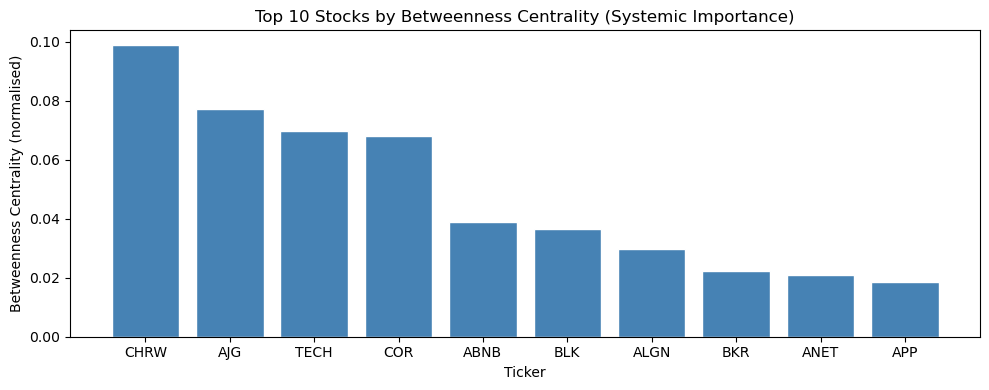

In [28]:
# Betweenness centrality — how often a node lies on shortest paths between others
betweenness = nx.betweenness_centrality(G, normalized=True)
in_deg      = dict(G.in_degree())
out_deg     = dict(G.out_degree())

# Build summary table
centrality_rows = []
for node in G.nodes():
    ticker = cols[node]
    centrality_rows.append({
        "Ticker":      ticker,
        "Sector":      sector_map.get(ticker, "Unknown"),
        "Betweenness": round(betweenness[node], 4),
        "Out-degree":  out_deg[node],
        "In-degree":   in_deg[node],
    })

centrality_df = (
    pd.DataFrame(centrality_rows)
    .sort_values("Betweenness", ascending=False)
    .reset_index(drop=True)
)

print("=" * 58)
print(f"{'Rank':<5} {'Ticker':<8} {'Betweenness':>12}  {'Out':>4}  {'In':>4}  Sector")
print("=" * 58)
for rank, row in centrality_df.head(10).iterrows():
    print(
        f"{rank+1:<5} {row['Ticker']:<8} {row['Betweenness']:>12.4f}"
        f"  {row['Out-degree']:>4}  {row['In-degree']:>4}  {row['Sector']}"
    )
print("=" * 58)

# Bar chart
fig_c, ax_c = plt.subplots(figsize=(10, 4))
top10 = centrality_df.head(10)
ax_c.bar(top10["Ticker"], top10["Betweenness"], color="steelblue", edgecolor="white")
ax_c.set_title("Top 10 Stocks by Betweenness Centrality (Systemic Importance)")
ax_c.set_ylabel("Betweenness Centrality (normalised)")
ax_c.set_xlabel("Ticker")
plt.tight_layout()
plt.show()


## Issuers At Risk: Composite Early-Warning Ranking

This table turns the GARJI filter and causal network into a practical **issuer risk monitor**.
Each issuer receives a composite score built from seven components:

- current own jump probability
- current volatility stress relative to its own history
- average stress coming from parent issuers in the causal graph
- maximum parent jump probability to capture concentrated contagion risk
- in-degree as a measure of contagion vulnerability
- betweenness as a measure of systemic transmission exposure
- sector jump risk from the pooled GARJI jump block

The weighting is intentionally tilted toward **current issuer stress** so that names rank highly
only when they show either elevated jump risk, elevated volatility stress, or both.
The output includes both the **raw component values** and their **normalised score contributions**,
so the ranking remains explainable rather than a black box.

Top 10 Issuers At Risk
  Ticker                  Sector        Date  RiskScore  JumpProb    VolZ  ParentStress  MaxParentJump  InDegree  OutDegree  Betweenness  SectorJumpRisk  JumpScore  VolScore  ParentScore  MaxParentScore  InDegreeScore  BetweennessScore  SectorScore  TopParents
0   AXON             Industrials  2025-05-30     0.5543    0.0394 -0.4628        0.0129         0.0150         2          0       0.0000          1.2144     1.0000       0.0       0.4326          0.5039            1.0            0.0000       0.2853    APP, AMP
1    ALB               Materials  2025-05-30     0.4582    0.0312 -0.7792        0.0116         0.0150         2          0       0.0000          1.2305     0.7369       0.0       0.3892          0.5039            1.0            0.0000       0.5970   APP, CHRW
2    AJG              Financials  2025-05-30     0.4510    0.0298 -0.6274        0.0117         0.0135         2          3       0.0774          1.2027     0.6942       0.0       0.3916        

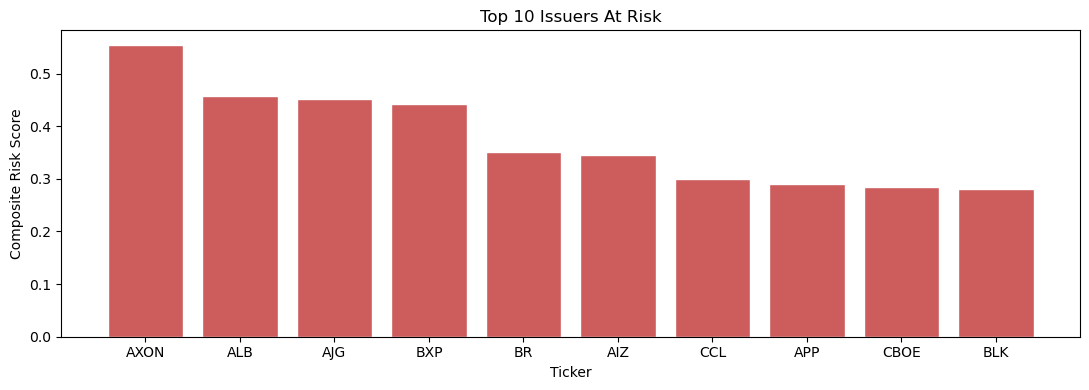

In [29]:
def minmax_scale(series):
    series = pd.Series(series, dtype=np.float64)
    finite = series.replace([np.inf, -np.inf], np.nan)
    lo = finite.min()
    hi = finite.max()
    if pd.isna(lo) or pd.isna(hi) or np.isclose(hi, lo):
        return pd.Series(0.0, index=series.index)
    return (finite - lo) / (hi - lo)


latest_date = volatilities.index[-1]
lookback = min(60, len(volatilities))
vol_window = volatilities.iloc[-lookback:]
jp_latest = jump_probs.loc[latest_date].reindex(cols).fillna(0.0)
vol_latest = volatilities.loc[latest_date].reindex(cols)
vol_mean = vol_window.mean().reindex(cols)
vol_std = vol_window.std(ddof=0).replace(0, np.nan).reindex(cols)
vol_z = ((vol_latest - vol_mean) / vol_std).replace([np.inf, -np.inf], np.nan).fillna(0.0)

sector_raw_risk = {}
for sector, pooled in sector_jump_pool.items():
    sector_raw_risk[sector] = (
        abs(pooled["mu_j"]) + pooled["sigma_j"] + pooled["phi_l"] + pooled["gamma_l"]
    )

risk_rows = []
for node in G.nodes():
    ticker = cols[node]
    sector = sector_map.get(ticker, "Unknown")
    parents = list(G.predecessors(node))
    parent_tickers = [cols[parent] for parent in parents]
    parent_jump_values = jp_latest.reindex(parent_tickers).fillna(0.0)
    parent_stress = float(parent_jump_values.mean()) if len(parent_tickers) else 0.0
    max_parent_jump = float(parent_jump_values.max()) if len(parent_tickers) else 0.0
    top_parents = ", ".join(parent_jump_values.sort_values(ascending=False).head(3).index.tolist())

    risk_rows.append({
        "Ticker": ticker,
        "Sector": sector,
        "Date": latest_date.strftime("%Y-%m-%d"),
        "JumpProb": float(jp_latest[ticker]),
        "VolZ": float(vol_z[ticker]),
        "ParentStress": parent_stress,
        "MaxParentJump": max_parent_jump,
        "InDegree": int(in_deg[node]),
        "OutDegree": int(out_deg[node]),
        "Betweenness": float(betweenness[node]),
        "SectorJumpRisk": float(sector_raw_risk.get(sector, 0.0)),
        "TopParents": top_parents if top_parents else "-",
    })

issuer_risk_df = pd.DataFrame(risk_rows)

issuer_risk_df["JumpScore"] = minmax_scale(issuer_risk_df["JumpProb"])
issuer_risk_df["VolScore"] = minmax_scale(issuer_risk_df["VolZ"].clip(lower=0.0))
issuer_risk_df["ParentScore"] = minmax_scale(issuer_risk_df["ParentStress"])
issuer_risk_df["MaxParentScore"] = minmax_scale(issuer_risk_df["MaxParentJump"])
issuer_risk_df["InDegreeScore"] = minmax_scale(issuer_risk_df["InDegree"])
issuer_risk_df["BetweennessScore"] = minmax_scale(issuer_risk_df["Betweenness"])
issuer_risk_df["SectorScore"] = minmax_scale(issuer_risk_df["SectorJumpRisk"])

issuer_risk_df["RiskScore"] = (
    0.40 * issuer_risk_df["JumpScore"]
    + 0.25 * issuer_risk_df["VolScore"]
    + 0.15 * issuer_risk_df["ParentScore"]
    + 0.05 * issuer_risk_df["MaxParentScore"]
    + 0.05 * issuer_risk_df["InDegreeScore"]
    + 0.05 * issuer_risk_df["BetweennessScore"]
    + 0.05 * issuer_risk_df["SectorScore"]
)

issuer_risk_df = issuer_risk_df.sort_values(
    ["RiskScore", "JumpProb", "VolZ", "ParentStress"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

risk_display_cols = [
    "Ticker", "Sector", "Date", "RiskScore",
    "JumpProb", "VolZ", "ParentStress", "MaxParentJump",
    "InDegree", "OutDegree", "Betweenness", "SectorJumpRisk",
    "JumpScore", "VolScore", "ParentScore", "MaxParentScore",
    "InDegreeScore", "BetweennessScore", "SectorScore", "TopParents",
]

risk_display = issuer_risk_df[risk_display_cols].copy()
for col in [
    "RiskScore", "JumpProb", "VolZ", "ParentStress", "MaxParentJump",
    "Betweenness", "SectorJumpRisk", "JumpScore", "VolScore",
    "ParentScore", "MaxParentScore", "InDegreeScore", "BetweennessScore", "SectorScore",
]:
    risk_display[col] = risk_display[col].astype(float).round(4)

print("=" * 140)
print("Top 10 Issuers At Risk")
print("=" * 140)
print(risk_display.head(10).to_string(index=True))
print("=" * 140)

fig_r, ax_r = plt.subplots(figsize=(11, 4))
top_risk = risk_display.head(10)
ax_r.bar(top_risk["Ticker"], top_risk["RiskScore"], color="indianred", edgecolor="white")
ax_r.set_title("Top 10 Issuers At Risk")
ax_r.set_ylabel("Composite Risk Score")
ax_r.set_xlabel("Ticker")
plt.tight_layout()
plt.show()

## Out-of-Sample Backtest

Replicate the paper's warning-signal evaluation and compare it with simpler baselines:
- Train on the first 80% of the sample.
- For each day in the test set, if a *father* node exhibits a jump probability above the threshold,
  issue a **warning** for each *son* (child) in the causal graph.
- A warning is a *true positive* if the son's volatility exceeds
  `mean_train + 1.5 × std_train` on the next day.
- Compare the network-guided warning rule with:
  - an own-jump baseline that only warns on the same issuer,
  - the raw event rate in the test sample as a naive precision reference.

In [30]:
def finalize_backtest_metrics(tp, fp, total_events, train_end, test_start):
    warnings = tp + fp
    precision = tp / max(warnings, 1)
    recall = tp / max(total_events, 1)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
    return {
        "warnings": warnings,
        "TP": tp,
        "FP": fp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "train_end": train_end,
        "test_start": test_start,
    }


def run_backtest(vol_df, jp_df, adj_mat, ticker_cols,
                 train_frac=0.8, jump_thr=0.5, vol_z=1.5):
    """
    Out-of-sample backtest following the paper's father/son warning protocol.
    Father node: emits a warning when jump_prob > jump_thr.
    Warning: son will have elevated volatility on the next period.
    """
    total_obs = len(vol_df)
    train_size = int(total_obs * train_frac)

    vol_train = vol_df.iloc[:train_size]
    vol_test = vol_df.iloc[train_size:]
    jp_test = jp_df.loc[vol_test.index]

    thresholds = vol_train.mean() + vol_z * vol_train.std()
    graph_bt = adjacency_to_digraph(adj_mat)

    total_events = 0
    true_positives = 0
    false_positives = 0
    dates = vol_test.index

    for t in range(1, len(dates)):
        prev_date, curr_date = dates[t - 1], dates[t]
        total_events += int((vol_test.loc[curr_date] > thresholds).sum())
        for parent_idx, ticker in enumerate(ticker_cols):
            if jp_test.loc[prev_date, ticker] < jump_thr:
                continue

            for child_idx in graph_bt.successors(parent_idx):
                child_ticker = ticker_cols[child_idx]
                if vol_test.loc[curr_date, child_ticker] > thresholds[child_ticker]:
                    true_positives += 1
                else:
                    false_positives += 1

    return finalize_backtest_metrics(
        true_positives,
        false_positives,
        total_events,
        vol_df.index[train_size - 1].strftime("%Y-%m-%d"),
        vol_df.index[train_size].strftime("%Y-%m-%d"),
    )


def run_self_jump_baseline(vol_df, jp_df, ticker_cols,
                           train_frac=0.8, jump_thr=0.5, vol_z=1.5):
    """Baseline: warn only on the same issuer when its own jump probability is elevated."""
    total_obs = len(vol_df)
    train_size = int(total_obs * train_frac)

    vol_train = vol_df.iloc[:train_size]
    vol_test = vol_df.iloc[train_size:]
    jp_test = jp_df.loc[vol_test.index]

    thresholds = vol_train.mean() + vol_z * vol_train.std()
    total_events = 0
    true_positives = 0
    false_positives = 0
    dates = vol_test.index

    for t in range(1, len(dates)):
        prev_date, curr_date = dates[t - 1], dates[t]
        total_events += int((vol_test.loc[curr_date] > thresholds).sum())
        for ticker in ticker_cols:
            if jp_test.loc[prev_date, ticker] < jump_thr:
                continue
            if vol_test.loc[curr_date, ticker] > thresholds[ticker]:
                true_positives += 1
            else:
                false_positives += 1

    return finalize_backtest_metrics(
        true_positives,
        false_positives,
        total_events,
        vol_df.index[train_size - 1].strftime("%Y-%m-%d"),
        vol_df.index[train_size].strftime("%Y-%m-%d"),
    )


def compute_test_event_rate(vol_df, train_frac=0.8, vol_z=1.5):
    """Naive reference precision from the share of stressed issuer-days in the test period."""
    total_obs = len(vol_df)
    train_size = int(total_obs * train_frac)
    vol_train = vol_df.iloc[:train_size]
    vol_test = vol_df.iloc[train_size:]
    thresholds = vol_train.mean() + vol_z * vol_train.std()

    if len(vol_test) <= 1:
        return 0.0

    stressed = 0
    total_slots = 0
    for curr_date in vol_test.index[1:]:
        stressed += int((vol_test.loc[curr_date] > thresholds).sum())
        total_slots += len(vol_test.columns)

    return stressed / max(total_slots, 1)


print("Running out-of-sample backtest ...")
bt = run_backtest(volatilities, jump_probs, adj_matrix, cols,
                  train_frac=0.8, jump_thr=0.5, vol_z=1.5)
self_bt = run_self_jump_baseline(volatilities, jump_probs, cols,
                                 train_frac=0.8, jump_thr=0.5, vol_z=1.5)
event_rate = compute_test_event_rate(volatilities, train_frac=0.8, vol_z=1.5)

comparison_df = pd.DataFrame([
    {
        "Model": "Network-guided",
        "Warnings": bt["warnings"],
        "TP": bt["TP"],
        "FP": bt["FP"],
        "Precision": bt["precision"],
        "Recall": bt["recall"],
        "F1": bt["f1"],
    },
    {
        "Model": "Own-jump baseline",
        "Warnings": self_bt["warnings"],
        "TP": self_bt["TP"],
        "FP": self_bt["FP"],
        "Precision": self_bt["precision"],
        "Recall": self_bt["recall"],
        "F1": self_bt["f1"],
    },
])

for col in ["Precision", "Recall", "F1"]:
    comparison_df[col] = comparison_df[col].astype(float).round(3)

print(f"\n{'=' * 64}")
print(f"Backtest comparison (train through {bt['train_end']}, test from {bt['test_start']})")
print(f"{'=' * 64}")
print(comparison_df.to_string(index=False))
print(f"\nNaive test event rate reference: {event_rate:.3f}")

Running out-of-sample backtest ...

Backtest comparison (train through 2025-01-03, test from 2025-01-06)
            Model  Warnings  TP  FP  Precision  Recall    F1
   Network-guided       207  70 137      0.338   0.180 0.235
Own-jump baseline       123  50  73      0.407   0.129 0.196

Naive test event rate reference: 0.135


## Visualize the Causal Network

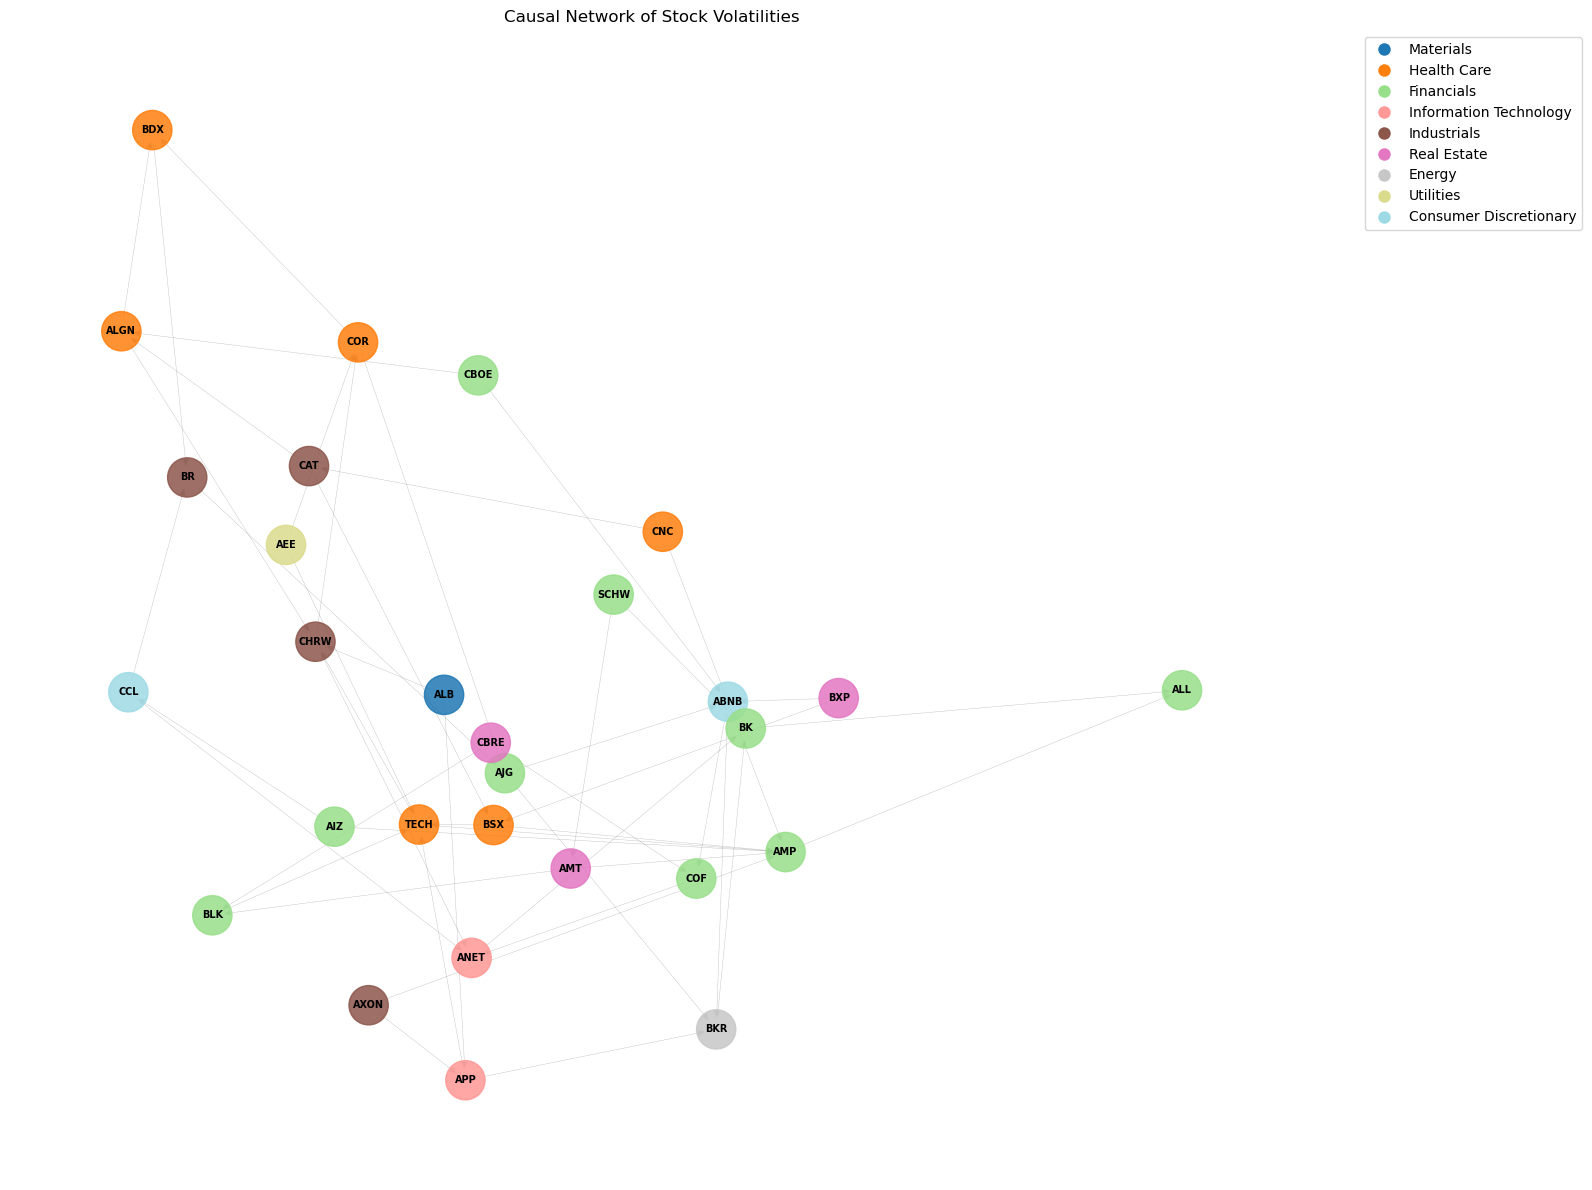

In [21]:
plt.figure(figsize=(16, 12))
sectors = set(nx.get_node_attributes(G, 'sector').values())
palette = plt.cm.tab20(np.linspace(0, 1, len(sectors)))
color_map = {sector: palette[i] for i, sector in enumerate(sectors)}
node_colors = [color_map[G.nodes[n]['sector']] for n in G.nodes()]
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_edges(G, pos, edge_color='gray', width=0.3, alpha=0.5, arrows=True)
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, alpha=0.85)

labels = {n: G.nodes[n]['ticker'] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, font_weight='bold')

patches = [
    plt.Line2D([0], [0], marker='o', color='w',
              markerfacecolor=color_map[s], markersize=10, label=s)
    for s in sectors
]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Causal Network of Stock Volatilities")
plt.axis('off')
plt.tight_layout()
plt.show()


TOP_RISK
Ticker  RiskScore  JumpProb    VolZ  ParentStress
  AXON     0.5543    0.0394 -0.4628        0.0129
   ALB     0.4582    0.0312 -0.7792        0.0116
   AJG     0.4510    0.0298 -0.6274        0.0117
   BXP     0.4414    0.0324 -0.4935        0.0114
    BR     0.3506    0.0164 -0.5668        0.0298
   AIZ     0.3448    0.0230 -0.4212        0.0143
   CCL     0.2997    0.0178 -0.8034        0.0148
   APP     0.2904    0.0150 -1.2261        0.0133
  CBOE     0.2853    0.0179 -0.4629        0.0155
   BLK     0.2809    0.0115 -0.6644        0.0233

HEADLINE
{'max_parents': 2, 'max_children': 6, 'network_precision': 0.338, 'baseline_precision': 0.407, 'event_rate': 0.135}
